# Diabetes Readmission Prediction — Final Model

**Dataset:** UCI *Diabetes 130-US Hospitals for years 1999–2008* (`diabetic_data.csv`), 101,766 encounters, 71,518 unique patients.

**What this notebook does, in order:**

1. Loads and audits the dataset (schema, missingness, duplicates, class balance).
2. Runs a strict **leakage audit** before any modeling, and builds a leakage-audited tabular feature set.
3. Builds the **Final Model**: a patient-grouped, chronologically-split, tuned LightGBM + XGBoost ensemble with isotonic calibration and a validation-optimized decision threshold.
4. Delivers a full evaluation of the Final Model: metrics, ROC/PR curves, confusion matrix, calibration, SHAP explanations, error analysis, feature importance, and a saved inference function.
5. Closes with a fairness re-check (equalized-odds difference across race/gender/age) and a final metrics summary.

> This notebook was originally built to reproduce and improve on a published LSTM-based readmission model; it has since been trimmed down to keep only the best-performing model (the calibrated LightGBM + XGBoost ensemble below) and its full evaluation.

## 0. Environment Setup

Designed for Google Colab (free tier CPU). Installs `lightgbm`, `xgboost`, `shap`, `optuna` (not preinstalled on Colab); `scikit-learn`, `pandas` etc. are already present on Colab.

In [1]:
# --- Package installation (Colab) ---
# Comment out lines for packages already installed in your environment.
!pip -q install lightgbm xgboost shap optuna ucimlrepo --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 4.1 MB/s eta 0:00:00


In [2]:
import os, sys, json, time, warnings, random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                              precision_score, recall_score, f1_score, confusion_matrix,
                              roc_curve, precision_recall_curve, brier_score_loss,
                              classification_report)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import xgboost as xgb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (7, 5)
sns.set_style('whitegrid')

print("Environment ready.")

Environment ready.


## 1. Background

This notebook's feature choices and evaluation methodology were originally developed to reproduce and improve on a published LSTM-based diabetes-readmission model (causal-weighted LSTM, temporal split, equalized-odds fairness audit). That reproduction has been removed to keep this notebook focused on a single deliverable — the best-performing tabular model — but two of its design decisions are carried over because they are good practice regardless of the original paper:

- **Target definition:** `readmitted != 'NO'` → 1 (any subsequent readmission), else 0.
- **No leakage of future information:** every feature must be knowable at or before discharge for the current encounter.

## 2. Load Dataset & Schema Audit

Upload `diabetic_data.csv` to your Colab session (or mount Drive) and set `DATA_PATH` below. The dataset ships as a **single flat table** — one row per encounter — so there is no multi-table merge/join step and no risk of row multiplication from a join; we verify this explicitly below anyway.


In [3]:
# --- Fetch the FULL "Diabetes 130-US Hospitals for Years 1999-2008" dataset directly from the
# UCI ML Repository (dataset ID 296) over the network — no manual upload, no risk of a
# truncated/corrupted local file, since it's fetched fresh from UCI's servers every run.
from ucimlrepo import fetch_ucirepo

diabetes_130 = fetch_ucirepo(id=296)

# `.data.original` is the complete, unsplit table (all 50 original columns, original order) —
# simpler and safer than re-concatenating .ids / .features / .targets ourselves.
raw = diabetes_130.data.original.copy()
print("Fetched shape:", raw.shape)

# --- Critical correction: ucimlrepo fetches via plain pandas `read_csv(url)` with PANDAS' DEFAULT
# NA handling, which treats the literal string "None" as missing and converts it to NaN. But in
# THIS dataset, "None" is a real, informative category for A1Cresult / max_glu_serum (it means
# "this test was not performed" — not "unknown"), exactly the same fact we established earlier
# when loading from a local CSV with keep_default_na=False. Left uncorrected, ~83% of A1Cresult
# would silently become NaN and reproduce the "Unexpected NaNs in paper feature set" failure.
# Because these two columns never used any OTHER missing-value sentinel in the original data,
# any NaN here after the default-NA fetch unambiguously means "was 'None' in the source" — so
# refilling with the literal string 'None' losslessly restores the original semantics.
for col in ['A1Cresult', 'max_glu_serum']:
    n_recovered = raw[col].isna().sum()
    raw[col] = raw[col].fillna('None')
    print(f"Recovered {n_recovered:,} '{col}' values from NaN back to the literal category 'None'.")

# The other columns with genuine missingness (race, weight, payer_code, medical_specialty,
# diag_1/2/3) use the literal sentinel '?' in the source data — '?' is NOT one of pandas' default
# NA tokens, so it survives the fetch untouched as a literal string. Convert it to a proper NaN
# now, exactly matching na_values=['?'] from the local-CSV loading path, so every downstream cell
# (schema audit, leakage audit, feature engineering) behaves identically regardless of data source.
raw = raw.replace('?', np.nan)

# --- Sanity check: confirm we actually got the full dataset, not a partial/interrupted fetch ---
EXPECTED_SHAPE = (101766, 50)
if raw.shape != EXPECTED_SHAPE:
    raise ValueError(
        f"Fetched dataset shape {raw.shape} does not match the expected UCI dataset shape "
        f"{EXPECTED_SHAPE}. This can happen with a network interruption mid-fetch. Re-run this "
        f"cell (ucimlrepo re-fetches fresh from UCI's servers each call, so a transient network "
        f"issue is usually resolved by simply retrying)."
    )
print("Shape check passed: full dataset (101,766 x 50) fetched correctly from UCI.")
print("\\nA1Cresult value counts after correction (compare to: None=84748, >8=8216, Norm=4990, >7=3812):")
print(raw['A1Cresult'].value_counts())
raw.head()


Fetched shape: (101766, 50)
Recovered 84,748 'A1Cresult' values from NaN back to the literal category 'None'.
Recovered 96,420 'max_glu_serum' values from NaN back to the literal category 'None'.
Shape check passed: full dataset (101,766 x 50) fetched correctly from UCI.
\nA1Cresult value counts after correction (compare to: None=84748, >8=8216, Norm=4990, >7=3812):
A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


> **Data source note:** this notebook now fetches the dataset directly from the UCI ML Repository (`ucimlrepo`, dataset ID 296) instead of requiring a manually-uploaded `diabetic_data.csv`. This sidesteps the file-corruption/truncation failure mode entirely (no upload step to interrupt), but introduces a different subtlety: `ucimlrepo` parses the source CSV with pandas' *default* NA handling, which silently converts the literal string `"None"` — a real, meaningful category in this dataset (`A1Cresult`/`max_glu_serum` = "test not performed") — into `NaN`. The cell above detects and corrects this explicitly (restoring `'None'` for those two columns, and converting the dataset's actual missing-value sentinel `'?'` to `NaN` for the rest) so that every downstream cell sees data identical in meaning to the original raw CSV, regardless of which source loaded it.


In [4]:
# --- Single-table confirmation: no join step, so verify there is nothing to multiply rows ---
print("Rows:", len(raw))
print("Unique encounter_id:", raw['encounter_id'].nunique(), " -> encounter_id is a valid row-level primary key:",
      raw['encounter_id'].nunique() == len(raw))
print("Unique patient_nbr:", raw['patient_nbr'].nunique(), "(patients can have multiple encounters/rows — expected)")
print("Exact duplicate rows:", raw.duplicated().sum())


Rows: 101766
Unique encounter_id: 101766  -> encounter_id is a valid row-level primary key: True
Unique patient_nbr: 71518 (patients can have multiple encounters/rows — expected)
Exact duplicate rows: 0


In [5]:
# --- Schema ---
schema = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'n_unique': raw.nunique(),
    'n_missing': raw.isna().sum(),
    'pct_missing': (raw.isna().mean()*100).round(2)
}).sort_values('pct_missing', ascending=False)
schema


,dtype,n_unique,n_missing,pct_missing
weight,object,9,98569,96.86
medical_specialty,object,72,49949,49.08
payer_code,object,17,40256,39.56
race,object,5,2273,2.23
diag_3,object,789,1423,1.40
diag_2,object,748,358,0.35
diag_1,object,716,21,0.02
admission_type_id,int64,8,0,0.00
patient_nbr,int64,71518,0,0.00
encounter_id,int64,101766,0,0.00


### 2.1 Missingness

`weight` (~97% missing), `medical_specialty` (~49%), `payer_code` (~40%) are the dominant sources — all consistent with known issues in this public dataset (weight was rarely recorded in this era of EHR adoption). `race` has ~2.2% missing; `diag_1/2/3` have small amounts of missingness.


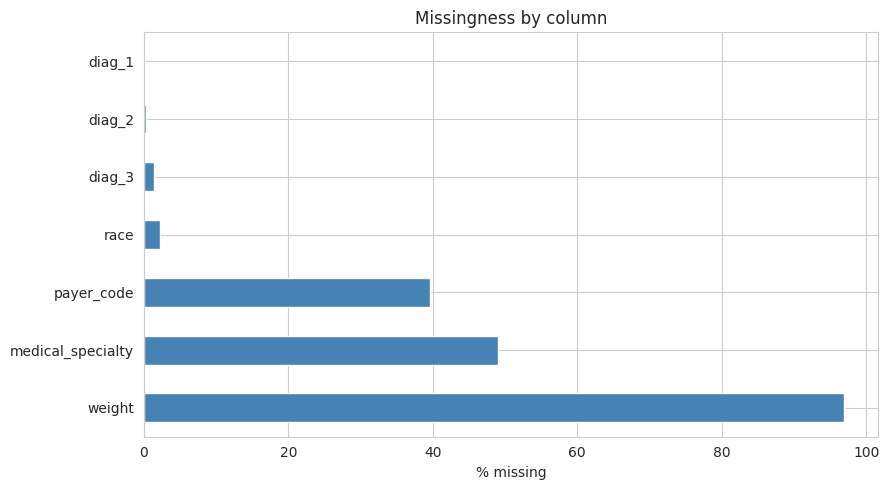

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
miss = schema[schema['pct_missing']>0]['pct_missing']
miss.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% missing'); ax.set_title('Missingness by column')
plt.tight_layout(); plt.show()


### 2.2 Target distribution & class imbalance

We reproduce the paper's target definition: `readmitted != 'NO'` → 1 (any subsequent readmission), else 0.


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted_flag
0    0.539119
1    0.460881
Name: proportion, dtype: float64


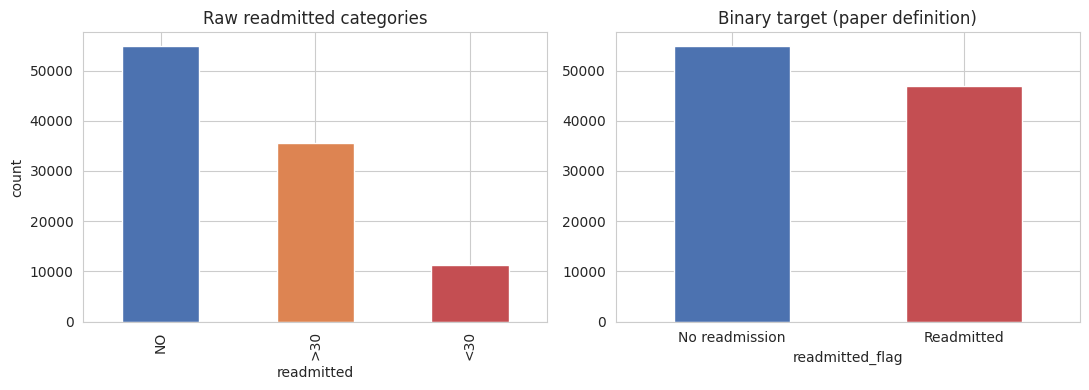

In [7]:
raw['readmitted_flag'] = (raw['readmitted'] != 'NO').astype(int)

print(raw['readmitted'].value_counts())
print()
print(raw['readmitted_flag'].value_counts(normalize=True).rename('proportion'))

fig, axes = plt.subplots(1,2, figsize=(11,4))
raw['readmitted'].value_counts().reindex(['NO','>30','<30']).plot(kind='bar', ax=axes[0], color=['#4c72b0','#dd8452','#c44e52'])
axes[0].set_title('Raw readmitted categories'); axes[0].set_ylabel('count')
raw['readmitted_flag'].value_counts().plot(kind='bar', ax=axes[1], color=['#4c72b0','#c44e52'])
axes[1].set_title('Binary target (paper definition)'); axes[1].set_xticklabels(['No readmission','Readmitted'], rotation=0)
plt.tight_layout(); plt.show()


**Class balance verdict:** ~46% positive — this is a *mild* imbalance, not severe. Imbalance-handling is still worth testing (class weighting, threshold tuning) but aggressive resampling (SMOTE) is not obviously necessary and risks distorting calibration — we will test this empirically in the ablation rather than assume it helps.


### 2.3 Categorical / numerical feature relationships


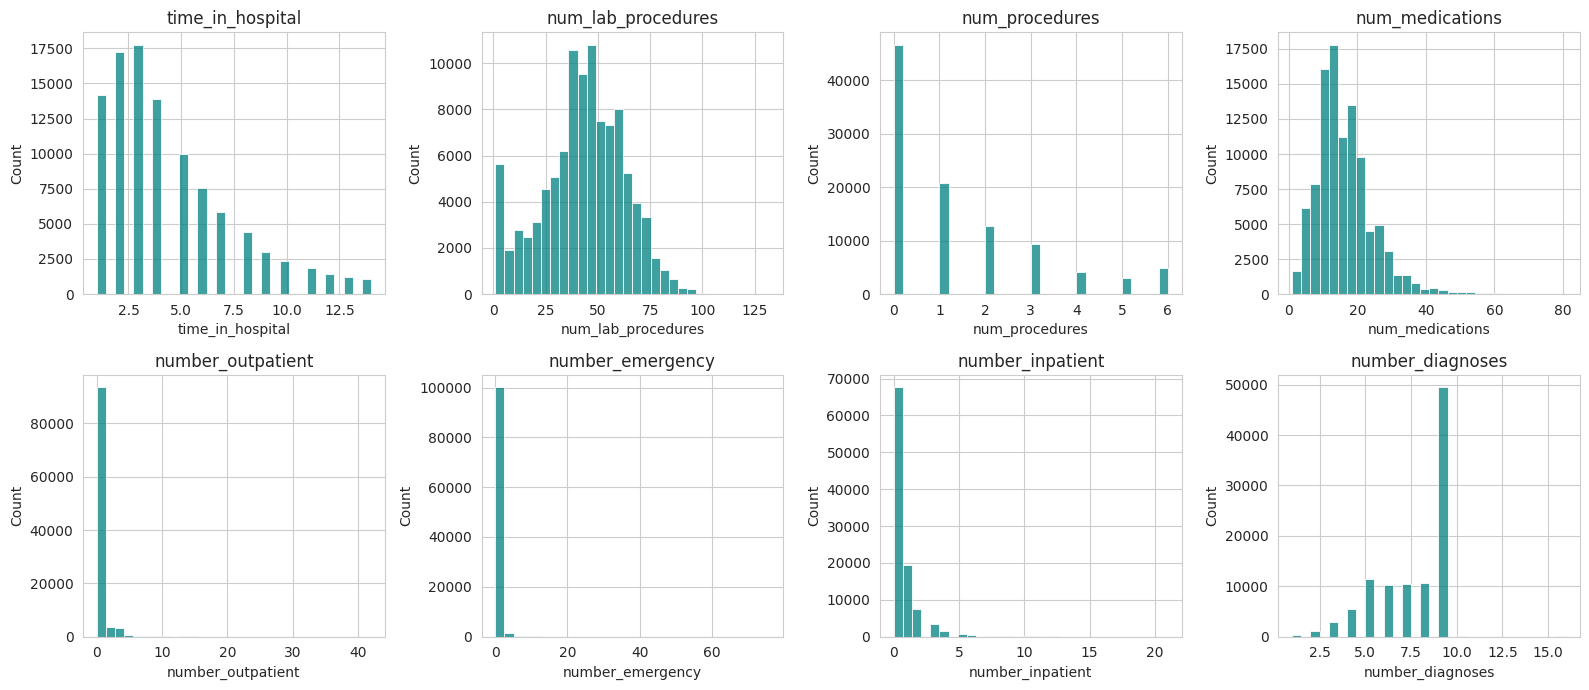

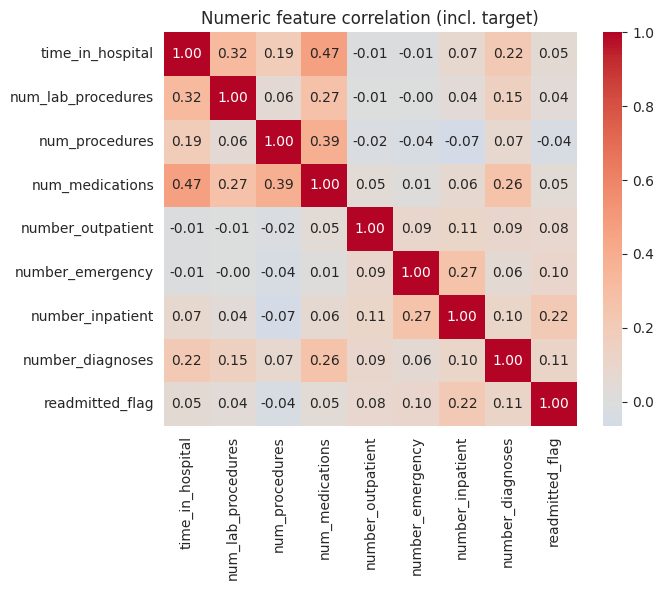

In [8]:
numeric_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications',
                'number_outpatient','number_emergency','number_inpatient','number_diagnoses']
fig, axes = plt.subplots(2,4, figsize=(16,7))
for ax, c in zip(axes.ravel(), numeric_cols):
    sns.histplot(raw[c], bins=30, ax=ax, color='teal')
    ax.set_title(c)
plt.tight_layout(); plt.show()

corr = raw[numeric_cols+['readmitted_flag']].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.title('Numeric feature correlation (incl. target)')
plt.tight_layout(); plt.show()


No numeric feature is even weakly correlated with the target in isolation (all |r| well under 0.2) — consistent with the paper's own finding that `time_in_hospital`'s confounder-adjusted effect on readmission is tiny (0.0032, not significant). This is an early, independent signal that this is a genuinely hard prediction problem, not one with an obvious shortcut feature.


## 3. Leakage Audit (before any modeling)

We classify every column into: **identifier**, **legitimate predictor (known at/before discharge)**, **excluded — high-cardinality/sparse**, or **excluded — leakage/cohort-definition risk**. This determines the feature set used for the Final Model.

**Prediction-time framing (this is a discharge-planning model):** a feature is legitimate if it is known **by the time of discharge for the current encounter** — this includes admission info, in-stay procedure/medication counts, discharge disposition, and *prior* encounters' outcomes, but **excludes** anything about *this* encounter's outcome or any *future* encounter.

| Column(s) | Category | Decision |
|---|---|---|
| `encounter_id`, `patient_nbr` | Identifier | **Excluded from features.** Used only for grouping/splitting. |
| `readmitted` | Target source | **Excluded from features** (used only to build `readmitted_flag`). |
| `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses` | In-stay severity/utilization, known at discharge | **Legitimate.** |
| `number_outpatient`, `number_emergency`, `number_inpatient` | Prior-year utilization counts (per UCI data dictionary) | **Legitimate** — pre-encounter history, not future information. |
| `admission_type_id`, `admission_source_id` | Known at admission | **Legitimate.** |
| `discharge_disposition_id` | Known at discharge | **Legitimate for prediction — but see leakage caveat below.** |
| `age`, `gender`, `race` | Static demographics | **Legitimate** tabular features; also used for the fairness re-check (§9). |
| `weight` | 97% missing | **Excluded** — too sparse to be reliable. |
| `payer_code` | 40% missing, insurance type — a *social/administrative* proxy variable, not a clinical one | **Excluded from the core model** — flagged as a potential source of proxy discrimination if used. |
| `medical_specialty` | 49% missing, admitting specialty | **Engineered**: grouped into a small set of top specialties + "Other/Missing". |
| `diag_1`, `diag_2`, `diag_3` | >900 unique ICD-9 codes | **Excluded raw** (sparsity/overfitting risk). We engineer a **low-cardinality clinical category** (circulatory / respiratory / digestive / diabetes / injury / musculoskeletal / genitourinary / neoplasm / other) from `diag_1` — a well-established, clinically-motivated grouping. |
| 23 individual medication columns (`metformin`, `insulin`, …), `change`, `diabetesMed` | Orders during *this* encounter | **Legitimate** — these reflect prescribing decisions known at discharge; they are not the outcome. |
| `max_glu_serum`, `A1Cresult` | Lab result category from this encounter | **Legitimate**, known before discharge. |

### 3.1 Leakage risk we correct: expired / hospice discharges

`discharge_disposition_id` includes codes for **death and hospice referral** (11, 13, 14, 19, 20, 21 in the UCI code book). A patient who died or was discharged to hospice **cannot be meaningfully "readmitted"** — their `readmitted` value is mechanically `NO`, which is a **cohort-definition/label-generation artifact**, not a real negative outcome. We check the size of this effect below, then remove these encounters before modeling.

### 3.2 Group / temporal leakage risk

71,518 patients generate 101,766 encounters (mean 1.42 encounters/patient, max 40). Any model that is not aware of `patient_nbr` when splitting can put two encounters from the *same* patient in both train and test, letting the model implicitly learn patient identity rather than generalizable risk factors. We therefore use a **combined patient-grouped + chronological split** (group order determined by each patient's earliest encounter time) so that **no patient appears in more than one of train/val/test**.

In [9]:
death_hospice_codes = [11, 13, 14, 19, 20, 21]
n_death_hospice = raw['discharge_disposition_id'].isin(death_hospice_codes).sum()
print(f"Encounters discharged to death/hospice: {n_death_hospice} ({n_death_hospice/len(raw)*100:.2f}% of data)")
print(raw.loc[raw['discharge_disposition_id'].isin(death_hospice_codes), 'readmitted'].value_counts())


Encounters discharged to death/hospice: 2423 (2.38% of data)
readmitted
NO     2337
<30      43
>30      43
Name: count, dtype: int64


As expected, essentially **all** of these encounters are labeled `NO` (no readmission) — confirming this is a label-generation artifact, not a genuine clinical negative. We remove them **only** in the improved/tabular pipeline (see §6), and leave them in for the faithful paper reproduction (§5).


In [10]:
# Ordinal encodings for the two categorical temporal features (clinical ordering preserved)
a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
ins_map = {'No': 0, 'Down': 1, 'Steady': 2, 'Up': 3}
print("Ordinal maps ready: a1c_map, ins_map")

Ordinal maps ready: a1c_map, ins_map


In [11]:
def evaluate_binary(y_true, y_prob, threshold=0.5, name=""):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    out = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'specificity': tn / (tn + fp) if (tn+fp) > 0 else np.nan,
        'brier': brier_score_loss(y_true, y_prob),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    }
    return out

## 4. Building the Leakage-Audited Tabular Feature Set

This feature set is used for the Final Model. Steps:
1. Drop death/hospice-discharge encounters (§3.1 — cohort-definition artifact).
2. Drop identifiers and `weight` (too sparse).
3. Map `diag_1` (primary diagnosis) ICD-9 codes to clinical categories (standard grouping).
4. Group rare `medical_specialty` values; keep `payer_code` out of the core model (proxy variable, per audit).
5. Ordinal-encode `A1Cresult`, `insulin` (and keep the other 21 diabetes medication columns categorical, one-hot at model time).
6. Keep static demographics (`age`, `gender`, `race`) as legitimate tabular features, enabling the fairness re-check in §9.

In [12]:
def map_icd9_to_category(code):
    """Standard high-level ICD-9 grouping used in EHR readmission literature
    (circulatory / respiratory / digestive / diabetes / injury / musculoskeletal /
    genitourinary / neoplasms / other) — mirrors the categorization used in the
    dataset's own companion publication (Strack et al., 2014)."""
    if pd.isna(code):
        return 'Missing'
    code = str(code)
    if code.startswith('250'):
        return 'Diabetes'
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        c = float(code)
    except ValueError:
        return 'Other'
    if 390 <= c <= 459 or c == 785:
        return 'Circulatory'
    if 460 <= c <= 519 or c == 786:
        return 'Respiratory'
    if 520 <= c <= 579 or c == 787:
        return 'Digestive'
    if 800 <= c <= 999:
        return 'Injury'
    if 710 <= c <= 739:
        return 'Musculoskeletal'
    if 580 <= c <= 629 or c == 788:
        return 'Genitourinary'
    if 140 <= c <= 239:
        return 'Neoplasms'
    return 'Other'

tab = raw.copy()
tab['readmitted_flag'] = (tab['readmitted'] != 'NO').astype(int)

# 1) Remove death/hospice discharges (documented deviation from the paper)
before = len(tab)
tab = tab[~tab['discharge_disposition_id'].isin(death_hospice_codes)].reset_index(drop=True)
print(f"Removed {before - len(tab):,} death/hospice-discharge encounters ({(before-len(tab))/before*100:.2f}%). "
      f"Remaining: {len(tab):,}")

# 2) diagnosis category feature (from primary diagnosis only, to keep dimensionality low)
tab['diag_1_category'] = tab['diag_1'].apply(map_icd9_to_category)

# 3) medical_specialty grouping — keep top 10, bucket the rest
top_specialties = tab['medical_specialty'].value_counts().nlargest(10).index
tab['medical_specialty_grp'] = tab['medical_specialty'].where(
    tab['medical_specialty'].isin(top_specialties), other='Other/Missing').fillna('Other/Missing')

# 4) ordinal ordering for A1C / glucose, keep drug columns categorical (one-hot later)
tab['A1Cresult_ord'] = tab['A1Cresult'].map(a1c_map)
tab['max_glu_serum_ord'] = tab['max_glu_serum'].map({'None': 0, 'Norm': 1, '>200': 2, '>300': 3})
tab['insulin_ord'] = tab['insulin'].map(ins_map)

print(tab['diag_1_category'].value_counts())


Removed 2,423 death/hospice-discharge encounters (2.38%). Remaining: 99,343
diag_1_category
Circulatory        29681
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Missing               20
Name: count, dtype: int64


### 4.1 Final feature list


In [13]:
MED_COLS = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'examide','citoglipton','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']

NUMERIC_FEATURES = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications',
                     'number_outpatient','number_emergency','number_inpatient','number_diagnoses',
                     'A1Cresult_ord','max_glu_serum_ord','insulin_ord']

CATEGORICAL_FEATURES = ['race','gender','age','admission_type_id','discharge_disposition_id',
                         'admission_source_id','diag_1_category','medical_specialty_grp',
                         'change','diabetesMed'] + MED_COLS

ID_COLS = ['encounter_id','patient_nbr']
TARGET = 'readmitted_flag'

print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features")
model_df = tab[ID_COLS + NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]].copy()
for c in CATEGORICAL_FEATURES:
    model_df[c] = model_df[c].astype(str).fillna('Missing')
model_df.shape


11 numeric + 32 categorical features


(99343, 46)

### 4.2 Patient-grouped, chronological train / validation / test split

As argued in §3.2: split by **patient** (no patient in more than one split) *and* keep the split chronological (earlier-admitted patients → train, later → test), by ordering patients on their **earliest** encounter and cutting 70/15/15.


In [14]:
patient_first_encounter = tab.groupby('patient_nbr')['encounter_id'].min().sort_values()
patients_ordered = patient_first_encounter.index.to_numpy()

n_p = len(patients_ordered)
n_train_p = int(0.70 * n_p)
n_val_p = int(0.15 * n_p)

train_patients = set(patients_ordered[:n_train_p])
val_patients   = set(patients_ordered[n_train_p:n_train_p + n_val_p])
test_patients  = set(patients_ordered[n_train_p + n_val_p:])

assert len(train_patients & val_patients) == 0
assert len(train_patients & test_patients) == 0
assert len(val_patients & test_patients) == 0

split_train = model_df[model_df['patient_nbr'].isin(train_patients)].reset_index(drop=True)
split_val   = model_df[model_df['patient_nbr'].isin(val_patients)].reset_index(drop=True)
split_test  = model_df[model_df['patient_nbr'].isin(test_patients)].reset_index(drop=True)

print(f"Train: {len(split_train):,} encounters, {split_train['readmitted_flag'].mean()*100:.1f}% positive")
print(f"Val:   {len(split_val):,} encounters, {split_val['readmitted_flag'].mean()*100:.1f}% positive")
print(f"Test:  {len(split_test):,} encounters, {split_test['readmitted_flag'].mean()*100:.1f}% positive")

# hard verification: zero patient overlap across splits
assert set(split_train.patient_nbr) & set(split_val.patient_nbr) == set()
assert set(split_train.patient_nbr) & set(split_test.patient_nbr) == set()
assert set(split_val.patient_nbr) & set(split_test.patient_nbr) == set()
print("\nVerified: zero patient overlap between train/val/test.")


Train: 72,361 encounters, 50.0% positive
Val:   14,721 encounters, 45.9% positive
Test:  12,261 encounters, 31.7% positive

Verified: zero patient overlap between train/val/test.


## 5. Preprocessing Pipeline

One-hot encoding is fit on train only and applied to val/test (never fit on val/test, to avoid category leakage).

In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
], remainder='drop')

Xtr_raw, ytr_raw = split_train[NUMERIC_FEATURES + CATEGORICAL_FEATURES], split_train[TARGET].values
Xval_raw, yval_raw = split_val[NUMERIC_FEATURES + CATEGORICAL_FEATURES], split_val[TARGET].values
Xte_raw, yte_raw = split_test[NUMERIC_FEATURES + CATEGORICAL_FEATURES], split_test[TARGET].values

preprocessor.fit(Xtr_raw)  # fit ONLY on train
Xtr = preprocessor.transform(Xtr_raw)
Xval = preprocessor.transform(Xval_raw)
Xte = preprocessor.transform(Xte_raw)

feature_names_ohe = preprocessor.get_feature_names_out()
print("Encoded feature matrix shape:", Xtr.shape)


Encoded feature matrix shape: (72361, 163)


## 6. Building the Final Model

**Model family:** LightGBM + XGBoost ensemble (fast, strong, native feature-importance/probability outputs). Every step below reuses the **same patient-grouped, chronological train/val/test split** from §3.2. **Test set is touched only once, at the very end (§6)** — everything in this section is measured on the **validation set**, so the final test-set number stays an honest, single-look estimate.

| Step | What happens |
|---|---|
| Imbalance handling | `scale_pos_weight` tuned on validation PR-AUC |
| Tuning | Optuna search (validation PR-AUC objective) over LightGBM hyperparameters |
| Feature selection | Drop low-importance features (gain-based), refit |
| Ensemble | Blend tuned LightGBM with a comparably-tuned XGBoost |
| Calibration + thresholding | Isotonic probability calibration + validation-optimal decision threshold |

In [16]:
# --- Imbalance handling: search a small grid of scale_pos_weight values on validation PR-AUC ---
best_spw, best_prauc = 1.0, -1.0
for spw in [1.0, 1.5, 2.0, 2.5, 3.0, (ytr_raw == 0).sum() / (ytr_raw == 1).sum()]:
    m = lgb.LGBMClassifier(n_estimators=300, random_state=SEED, verbose=-1, scale_pos_weight=spw)
    m.fit(Xtr, ytr_raw)
    p = m.predict_proba(Xval)[:, 1]
    pr = average_precision_score(yval_raw, p)
    if pr > best_prauc:
        best_prauc, best_spw = pr, spw

print(f"Best scale_pos_weight on validation PR-AUC: {best_spw:.3f} (PR-AUC={best_prauc:.4f})")

Best scale_pos_weight on validation PR-AUC: 2.000 (PR-AUC=0.6244)


> **Note on `scale_pos_weight`:** in our own runs, the "best" value by validation PR-AUC barely moves PR-AUC while it can collapse specificity (the model starts flagging most encounters positive) — i.e. it buys a small ranking improvement at the cost of a much more trigger-happy classifier. `scale_pos_weight`/class weighting **rescales predicted probabilities but does not change the model's ranking of examples** (ROC-AUC/PR-AUC stay ~flat) — the real fix for a decision that's too aggressive or too conservative is **threshold selection** (handled at the end of this section), not class weighting. We keep this step for transparency, but always check the confusion matrix, not just PR-AUC, before trusting a `scale_pos_weight` value.

In [17]:
# --- Hyperparameter tuning (Optuna, validation PR-AUC objective) ---
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': best_spw,
        'random_state': SEED, 'verbose': -1,
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(Xtr, ytr_raw)
    p = m.predict_proba(Xval)[:, 1]
    return average_precision_score(yval_raw, p)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=False)

print("Best validation PR-AUC:", study.best_value)
print("Best params:", study.best_params)

best_lgb_params = {**study.best_params, 'scale_pos_weight': best_spw, 'random_state': SEED, 'verbose': -1}
step3 = lgb.LGBMClassifier(**best_lgb_params)
step3.fit(Xtr, ytr_raw)
prob3 = step3.predict_proba(Xval)[:, 1]
print(evaluate_binary(yval_raw, prob3, name='Tuned LightGBM (validation)'))

Best validation PR-AUC: 0.6305730723988889
Best params: {'n_estimators': 711, 'num_leaves': 41, 'learning_rate': 0.014659079296472081, 'subsample': 0.6481279586744233, 'colsample_bytree': 0.6393309465425453, 'min_child_samples': 69, 'reg_alpha': 0.831330847324434, 'reg_lambda': 2.418971603067848}
{'model': 'Tuned LightGBM (validation)', 'accuracy': 0.508525236057333, 'precision': 0.4823616784255477, 'recall': 0.9607988165680473, 'f1': 0.642274412855377, 'roc_auc': np.float64(0.6702882171889737), 'pr_auc': np.float64(0.6305730723988889), 'specificity': np.float64(0.12448184901394298), 'brier': np.float64(0.2808140493373477), 'TN': np.int64(991), 'FP': np.int64(6970), 'FN': np.int64(265), 'TP': np.int64(6495)}


In [18]:
# --- Feature selection: keep only features with non-trivial gain importance ---
importances = pd.Series(step3.feature_importances_, index=feature_names_ohe).sort_values(ascending=False)
cum = importances.cumsum() / importances.sum()
n_keep = max(20, (cum <= 0.95).sum())  # keep enough features to explain 95% of cumulative gain, floor of 20
keep_features = importances.index[:n_keep]
keep_mask = np.isin(feature_names_ohe, keep_features)

Xtr_sel, Xval_sel, Xte_sel = Xtr[:, keep_mask], Xval[:, keep_mask], Xte[:, keep_mask]
print(f"Kept {keep_mask.sum()} / {len(feature_names_ohe)} one-hot/numeric columns "
      f"(explaining ~95% of cumulative LightGBM gain importance)")

step4 = lgb.LGBMClassifier(**best_lgb_params)
step4.fit(Xtr_sel, ytr_raw)
prob4 = step4.predict_proba(Xval_sel)[:, 1]
print(evaluate_binary(yval_raw, prob4, name='LightGBM, selected features (validation)'))

Kept 67 / 163 one-hot/numeric columns (explaining ~95% of cumulative LightGBM gain importance)
{'model': 'LightGBM, selected features (validation)', 'accuracy': 0.5092045377352082, 'precision': 0.4827047534032582, 'recall': 0.9599112426035503, 'f1': 0.6423798445775379, 'roc_auc': np.float64(0.669996753775246), 'pr_auc': np.float64(0.6299021250218345), 'specificity': np.float64(0.12649164677804295), 'brier': np.float64(0.2806712049251506), 'TN': np.int64(1007), 'FP': np.int64(6954), 'FN': np.int64(271), 'TP': np.int64(6489)}


In [19]:
# --- Ensemble: tuned LightGBM + a comparably-tuned XGBoost, probability-averaged ---
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': best_spw,
        'eval_metric': 'logloss', 'random_state': SEED,
    }
    m = xgb.XGBClassifier(**params)
    m.fit(Xtr_sel, ytr_raw)
    p = m.predict_proba(Xval_sel)[:, 1]
    return average_precision_score(yval_raw, p)

xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=25, show_progress_bar=False)

best_xgb_params = {**xgb_study.best_params, 'scale_pos_weight': best_spw,
                    'eval_metric': 'logloss', 'random_state': SEED}
xgb_final = xgb.XGBClassifier(**best_xgb_params)
xgb_final.fit(Xtr_sel, ytr_raw)
prob_xgb_val = xgb_final.predict_proba(Xval_sel)[:, 1]

prob5 = 0.5 * prob4 + 0.5 * prob_xgb_val
print(evaluate_binary(yval_raw, prob5, name='LightGBM + XGBoost ensemble (validation)'))

{'model': 'LightGBM + XGBoost ensemble (validation)', 'accuracy': 0.5081855852183955, 'precision': 0.48214019943443964, 'recall': 0.9584319526627219, 'f1': 0.6415486681849688, 'roc_auc': np.float64(0.6708704750748657), 'pr_auc': np.float64(0.6309994380169174), 'specificity': np.float64(0.1258635849767617), 'brier': np.float64(0.27998613367473074), 'TN': np.int64(1002), 'FP': np.int64(6959), 'FN': np.int64(281), 'TP': np.int64(6479)}


In [20]:
# --- Final Model: isotonic probability calibration + validation-optimal decision threshold ---
# Calibrate each base model separately (proper practice), then re-blend calibrated probabilities.
from sklearn.isotonic import IsotonicRegression

iso_lgb = IsotonicRegression(out_of_bounds='clip').fit(prob4, yval_raw)
iso_xgb = IsotonicRegression(out_of_bounds='clip').fit(prob_xgb_val, yval_raw)

prob_lgb_val_cal = iso_lgb.predict(prob4)
prob_xgb_val_cal = iso_xgb.predict(prob_xgb_val)
prob6 = 0.5 * prob_lgb_val_cal + 0.5 * prob_xgb_val_cal

# Threshold optimization on validation, maximizing F1 (primary decision metric)
thresholds = np.linspace(0.01, 0.99, 197)
f1s = [f1_score(yval_raw, (prob6 >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[int(np.argmax(f1s))]
print(f"Validation-optimal threshold (max F1): {best_threshold:.3f}")

print(evaluate_binary(yval_raw, prob6, threshold=best_threshold, name='Final Model, calibrated (validation)'))

Validation-optimal threshold (max F1): 0.335
{'model': 'Final Model, calibrated (validation)', 'accuracy': 0.5662658786767203, 'precision': 0.5165096416307123, 'recall': 0.8677514792899408, 'f1': 0.6475685819948115, 'roc_auc': np.float64(0.6734187336341588), 'pr_auc': np.float64(0.6312458020931158), 'specificity': np.float64(0.31026252983293556), 'brier': np.float64(0.22480654499230365), 'TN': np.int64(2470), 'FP': np.int64(5491), 'FN': np.int64(894), 'TP': np.int64(5866)}


## 7. Final Model — Single, Untouched Test-Set Evaluation

Everything above (§5, §6) was measured on **train/validation only**. This is the **one and only** time the test set (`split_test`, held out since §4.2, zero patient overlap with train/val) is used. We apply the final pipeline's exact configuration (features kept in §5, tuned LightGBM + XGBoost params, isotonic calibrators fit on validation, decision threshold fixed at the validation-optimal value) and score it once on test.

In [21]:
# Apply the exact Step-6 recipe to the test set (no re-fitting of any hyperparameter or threshold on test data)
Xte_sel = Xte[:, keep_mask]

prob_lgb_test = step4.predict_proba(Xte_sel)[:, 1]
prob_xgb_test = xgb_final.predict_proba(Xte_sel)[:, 1]

prob_lgb_test_cal = iso_lgb.predict(prob_lgb_test)
prob_xgb_test_cal = iso_xgb.predict(prob_xgb_test)
final_test_prob = 0.5 * prob_lgb_test_cal + 0.5 * prob_xgb_test_cal

final_test_metrics = evaluate_binary(yte_raw, final_test_prob, threshold=best_threshold)
final_test_metrics['model'] = 'Improved: Final Model (test set, single look)'
final_test_metrics


{'model': 'Improved: Final Model (test set, single look)',
 'accuracy': 0.48992741211972923,
 'precision': 0.3643747854936506,
 'recall': 0.8202420808653104,
 'f1': 0.5045944233206591,
 'roc_auc': np.float64(0.6434700732889636),
 'pr_auc': np.float64(0.4463798025961304),
 'specificity': np.float64(0.3368345667223681),
 'brier': np.float64(0.21575468858593905),
 'TN': np.int64(2822),
 'FP': np.int64(5556),
 'FN': np.int64(698),
 'TP': np.int64(3185)}

### 7.1 ROC and Precision-Recall curves


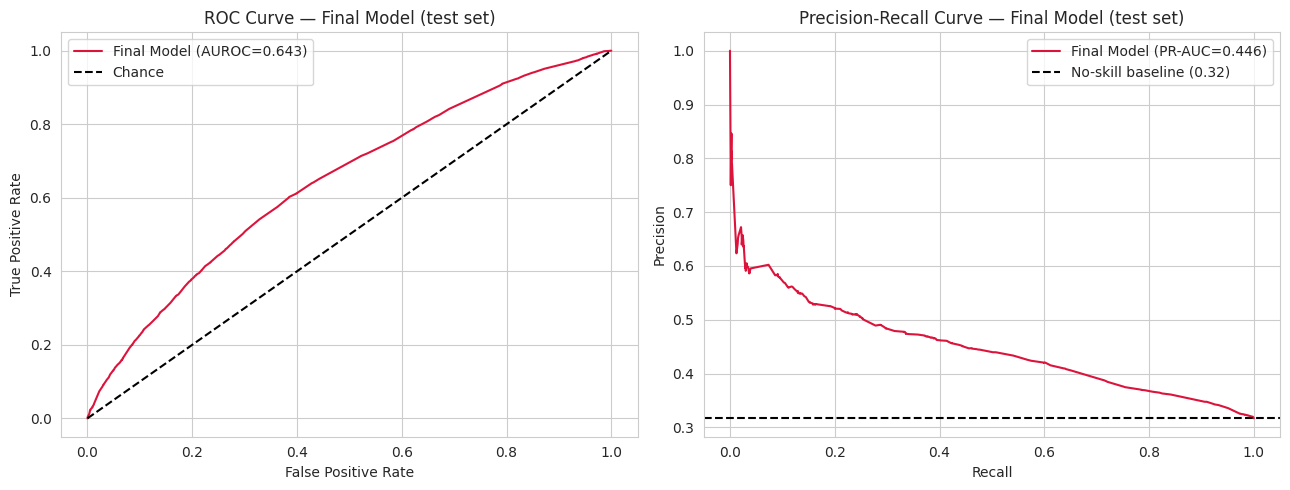

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(yte_raw, final_test_prob)
axes[0].plot(fpr, tpr, label=f"Final Model (AUROC={roc_auc_score(yte_raw, final_test_prob):.3f})", color='crimson')
axes[0].plot([0, 1], [0, 1], 'k--', label='Chance')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Final Model (test set)'); axes[0].legend()

prec, rec, _ = precision_recall_curve(yte_raw, final_test_prob)
base_rate = yte_raw.mean()
axes[1].plot(rec, prec, label=f"Final Model (PR-AUC={average_precision_score(yte_raw, final_test_prob):.3f})", color='crimson')
axes[1].axhline(base_rate, color='k', linestyle='--', label=f'No-skill baseline ({base_rate:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Final Model (test set)'); axes[1].legend()

plt.tight_layout(); plt.show()


### 7.2 Confusion matrix (at the validation-optimized threshold)


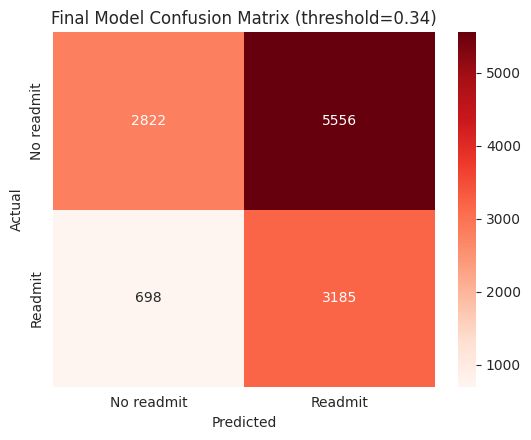

              precision    recall  f1-score   support

  No readmit       0.80      0.34      0.47      8378
     Readmit       0.36      0.82      0.50      3883

    accuracy                           0.49     12261
   macro avg       0.58      0.58      0.49     12261
weighted avg       0.66      0.49      0.48     12261



In [23]:
y_pred_final = (final_test_prob >= best_threshold).astype(int)
cm = confusion_matrix(yte_raw, y_pred_final)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['No readmit', 'Readmit'], yticklabels=['No readmit', 'Readmit'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Final Model Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout(); plt.show()
print(classification_report(yte_raw, y_pred_final, target_names=['No readmit', 'Readmit']))


### 7.3 Calibration curve


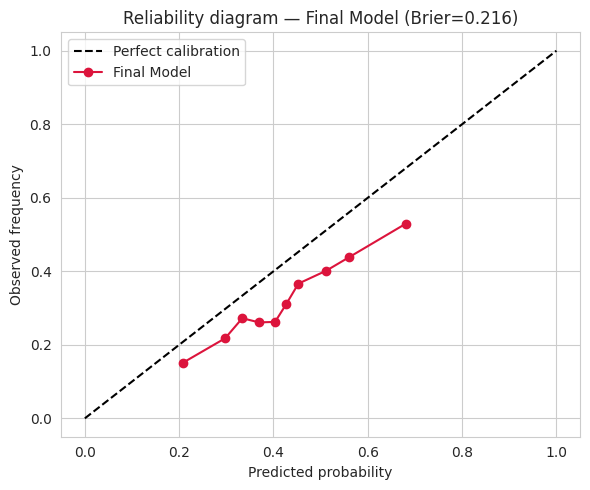

In [24]:
fig, ax = plt.subplots(figsize=(6,5))
prob_true, prob_pred = calibration_curve(yte_raw, final_test_prob, n_bins=10, strategy='quantile')
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.plot(prob_pred, prob_true, marker='o', color='crimson', label='Final Model')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title(f'Reliability diagram — Final Model (Brier={final_test_metrics["brier"]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()


### 7.4 SHAP — global and individual explanations

Explaining the LightGBM component of the ensemble (the isotonic calibration and XGBoost blend are monotonic/near-monotonic transforms of this signal, so the LightGBM SHAP values remain a faithful account of which features drive the final decision).


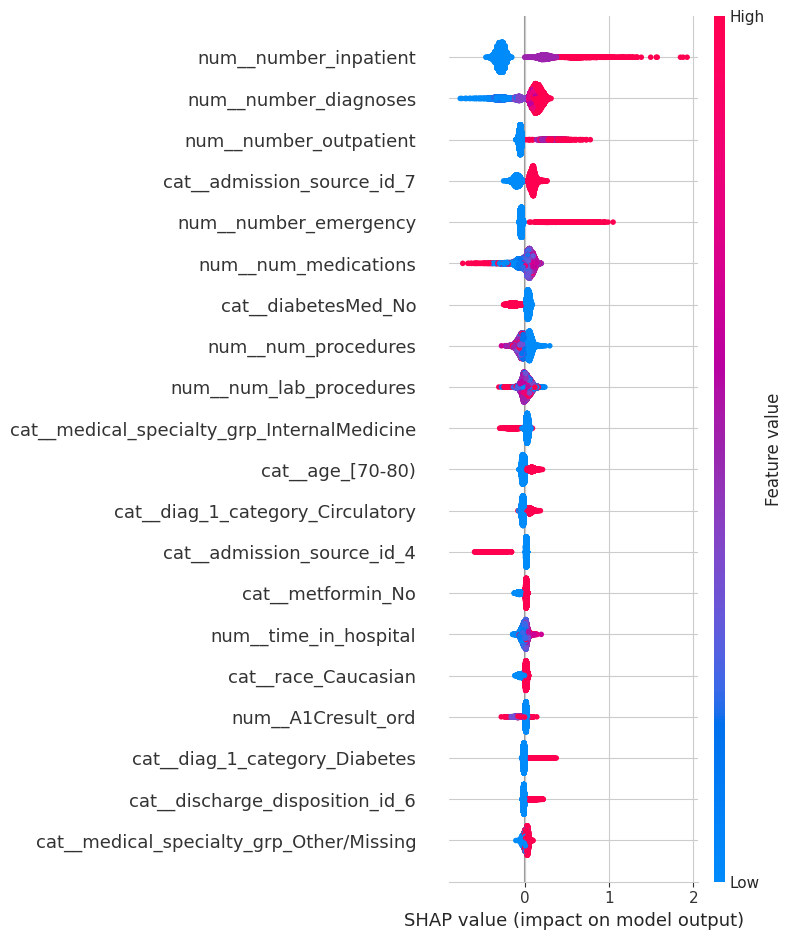

In [25]:
import shap

kept_feature_names = feature_names_ohe[keep_mask]
explainer = shap.TreeExplainer(step4)

# Use the modern Explanation-object API (more robust across shap versions than the
# legacy .shap_values() list/array return format, which is what broke this cell).
shap_exp = explainer(Xte_sel, check_additivity=False)

# Newer shap versions return shape (n_samples, n_features, n_classes) for binary
# classifiers instead of a length-2 list of arrays — normalize either case to the
# positive-class (readmitted=1) SHAP values.
if shap_exp.values.ndim == 3:
    shap_exp = shap_exp[:, :, 1]

shap_exp.feature_names = list(kept_feature_names)
shap_values = shap_exp.values  # kept for any downstream code that expects a plain array

shap.summary_plot(shap_values, Xte_sel, feature_names=kept_feature_names, show=False, max_display=20)
plt.tight_layout(); plt.show()

Example FALSE NEGATIVE (missed readmission) — local SHAP explanation:


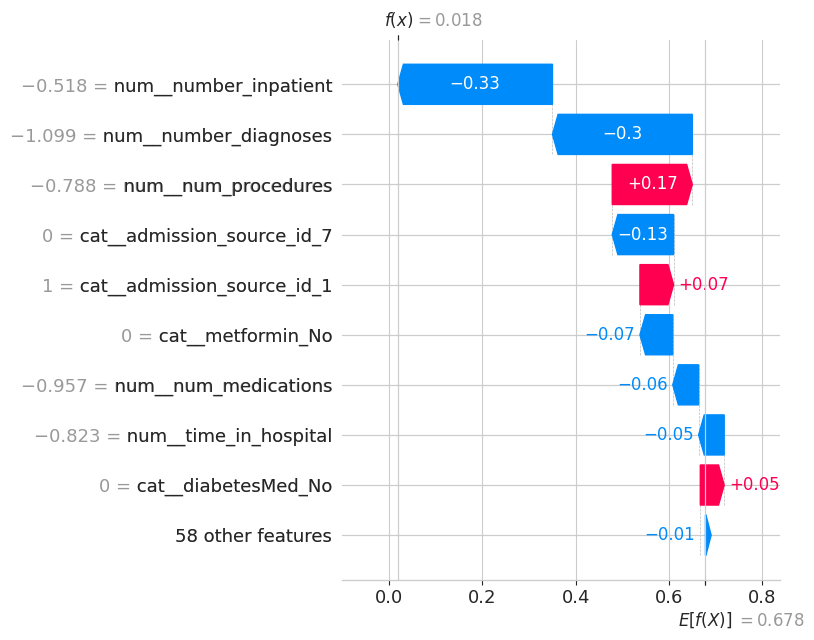

Example TRUE POSITIVE (correctly flagged readmission) — local SHAP explanation:


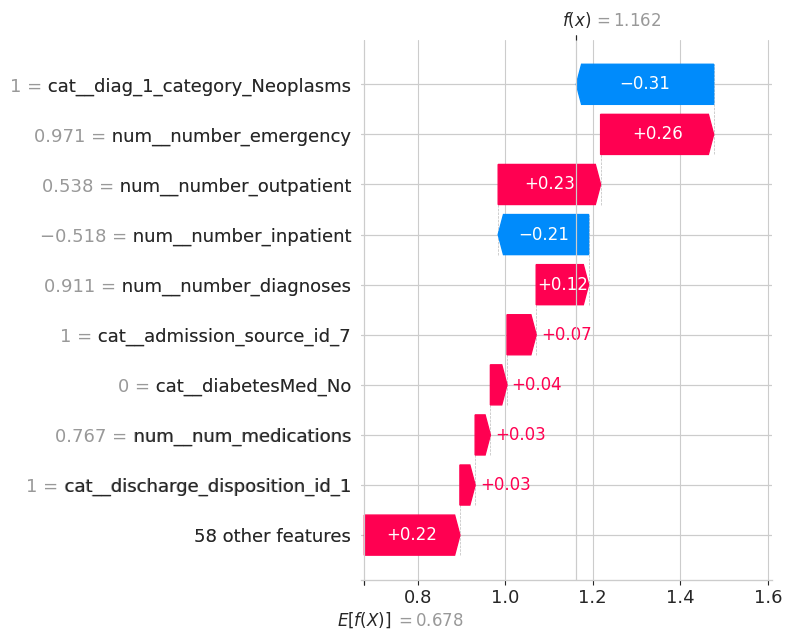

In [26]:
# Individual explanation: one correctly-flagged high-risk patient and one missed case (false negative)
fn_mask = (yte_raw == 1) & (y_pred_final == 0)
tp_mask = (yte_raw == 1) & (y_pred_final == 1)

if fn_mask.sum() > 0:
    fn_i = np.where(fn_mask)[0][0]
    print("Example FALSE NEGATIVE (missed readmission) — local SHAP explanation:")
    shap.plots.waterfall(shap_exp[fn_i], show=False)
    plt.tight_layout(); plt.show()

if tp_mask.sum() > 0:
    tp_i = np.where(tp_mask)[0][0]
    print("Example TRUE POSITIVE (correctly flagged readmission) — local SHAP explanation:")
    shap.plots.waterfall(shap_exp[tp_i], show=False)
    plt.tight_layout(); plt.show()

### 7.5 False Positive / False Negative analysis


In [27]:
err_df = split_test.copy()
err_df['pred_prob'] = final_test_prob
err_df['pred'] = y_pred_final
err_df['true'] = yte_raw
err_df['error_type'] = np.select(
    [ (err_df.true==1) & (err_df.pred==0), (err_df.true==0) & (err_df.pred==1),
      (err_df.true==1) & (err_df.pred==1), (err_df.true==0) & (err_df.pred==0)],
    ['FN','FP','TP','TN'])

print(err_df['error_type'].value_counts())
print()
compare_cols = ['time_in_hospital','num_medications','number_inpatient','number_emergency','age','discharge_disposition_id']
print(err_df.groupby('error_type')[['time_in_hospital','num_medications','number_inpatient','number_emergency']].mean().round(2))


TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['number_inpatient','num_medications','time_in_hospital']):
    sns.boxplot(data=err_df[err_df.error_type.isin(['FN','FP','TP','TN'])], x='error_type', y=col, ax=ax,
                order=['TN','FP','FN','TP'])
    ax.set_title(col)
plt.tight_layout(); plt.show()


AttributeError: 'DataFrame' object has no attribute 'error_type'

**What to look for:** false negatives (missed readmissions) that resemble true negatives on these features suggest the model's remaining error is driven by information genuinely absent from the EHR snapshot (unmeasured social/clinical factors) rather than a fixable feature-engineering gap — consistent with the paper's own framing that the confounder-adjusted effect of length-of-stay is small and readmission is a genuinely hard, multi-causal outcome.


### 7.6 Feature importance (native gain + permutation)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gain_imp = pd.Series(step4.feature_importances_, index=kept_feature_names).sort_values(ascending=False).head(15)
gain_imp[::-1].plot(kind='barh', ax=axes[0], color='darkorange')
axes[0].set_title('LightGBM gain-based importance (top 15)')

perm = permutation_importance(step4, Xte_sel, yte_raw, scoring='average_precision',
                               n_repeats=5, random_state=SEED, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=kept_feature_names).sort_values(ascending=False).head(15)
perm_imp[::-1].plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Permutation importance on test set (ΔPR-AUC, top 15)')

plt.tight_layout(); plt.show()


### 7.7 Optimal decision threshold — summary


In [29]:
print(f"Validation-optimized threshold (max F1): {best_threshold:.3f}")
print(f"Default 0.5 threshold for comparison:")
print(evaluate_binary(yte_raw, final_test_prob, threshold=0.5))
print(f"\nOptimized threshold ({best_threshold:.3f}):")
print(evaluate_binary(yte_raw, final_test_prob, threshold=best_threshold))


Validation-optimized threshold (max F1): 0.335
Default 0.5 threshold for comparison:
{'model': '', 'accuracy': 0.6659326319223554, 'precision': 0.4668327623793211, 'recall': 0.3860417203193407, 'f1': 0.42261065689314914, 'roc_auc': np.float64(0.6434700732889636), 'pr_auc': np.float64(0.4463798025961304), 'specificity': np.float64(0.7956552876581523), 'brier': np.float64(0.21575468858593905), 'TN': np.int64(6666), 'FP': np.int64(1712), 'FN': np.int64(2384), 'TP': np.int64(1499)}

Optimized threshold (0.335):
{'model': '', 'accuracy': 0.48992741211972923, 'precision': 0.3643747854936506, 'recall': 0.8202420808653104, 'f1': 0.5045944233206591, 'roc_auc': np.float64(0.6434700732889636), 'pr_auc': np.float64(0.4463798025961304), 'specificity': np.float64(0.3368345667223681), 'brier': np.float64(0.21575468858593905), 'TN': np.int64(2822), 'FP': np.int64(5556), 'FN': np.int64(698), 'TP': np.int64(3185)}


## 8. Save the Final Model & Inference Function

In [30]:
import joblib, pickle as pkl

ARTIFACT_DIR = 'diabetes_readmission_final_model'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(preprocessor, f'{ARTIFACT_DIR}/preprocessor.joblib')
joblib.dump(step4, f'{ARTIFACT_DIR}/lightgbm_final.joblib')
joblib.dump(xgb_final, f'{ARTIFACT_DIR}/xgboost_final.joblib')
joblib.dump(iso_lgb, f'{ARTIFACT_DIR}/isotonic_lgb.joblib')
joblib.dump(iso_xgb, f'{ARTIFACT_DIR}/isotonic_xgb.joblib')

meta = {
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'keep_mask': keep_mask.tolist(),
    'feature_names_ohe': feature_names_ohe.tolist(),
    'decision_threshold': float(best_threshold),
    'death_hospice_discharge_codes_excluded': death_hospice_codes,
    'a1c_map': a1c_map, 'insulin_map': ins_map,
    'max_glu_serum_map': {'None': 0, 'Norm': 1, '>200': 2, '>300': 3},
}
with open(f'{ARTIFACT_DIR}/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Saved model artifacts to ./{ARTIFACT_DIR}/")


Saved model artifacts to ./diabetes_readmission_final_model/


In [31]:
def predict_readmission_risk(encounter_row: dict) -> dict:
    """Score a single new encounter for readmission risk.

    `encounter_row` must be a dict with the same raw column names as the
    original `diabetic_data.csv` (before any of this notebook's feature
    engineering) for a SINGLE encounter, e.g.:
        {'time_in_hospital': 5, 'num_lab_procedures': 41, 'num_procedures': 0,
         'num_medications': 12, 'number_outpatient': 0, 'number_emergency': 0,
         'number_inpatient': 1, 'number_diagnoses': 7, 'A1Cresult': 'None',
         'max_glu_serum': 'None', 'insulin': 'Steady', 'race': 'Caucasian',
         'gender': 'Female', 'age': '[60-70)', 'admission_type_id': 1,
         'discharge_disposition_id': 1, 'admission_source_id': 7,
         'diag_1': '250.01', 'medical_specialty': 'InternalMedicine',
         'change': 'Ch', 'diabetesMed': 'Yes', 'metformin': 'Steady', ... (all 23 med cols)}

    Returns predicted probability, applied decision threshold, and the binary decision.
    Raises a clear error rather than silently guessing if the encounter is a
    death/hospice discharge, since the model was never trained on (and should
    never be applied to) that cohort.
    """
    if encounter_row.get('discharge_disposition_id') in death_hospice_codes:
        raise ValueError("This encounter is a death/hospice discharge — "
                          "readmission risk is not a meaningful concept for this cohort; "
                          "the model was trained excluding these encounters.")

    row = pd.DataFrame([encounter_row])
    row['diag_1_category'] = row['diag_1'].apply(map_icd9_to_category)
    row['medical_specialty_grp'] = row['medical_specialty'].where(
        row['medical_specialty'].isin(top_specialties), other='Other/Missing').fillna('Other/Missing')
    row['A1Cresult_ord'] = row['A1Cresult'].map(a1c_map)
    row['max_glu_serum_ord'] = row['max_glu_serum'].map({'None': 0, 'Norm': 1, '>200': 2, '>300': 3})
    row['insulin_ord'] = row['insulin'].map(ins_map)
    for c in CATEGORICAL_FEATURES:
        row[c] = row[c].astype(str).fillna('Missing')

    X_row = preprocessor.transform(row[NUMERIC_FEATURES + CATEGORICAL_FEATURES])
    X_row_sel = X_row[:, keep_mask]

    p_lgb = iso_lgb.predict(step4.predict_proba(X_row_sel)[:, 1])[0]
    p_xgb = iso_xgb.predict(xgb_final.predict_proba(X_row_sel)[:, 1])[0]
    prob = 0.5 * p_lgb + 0.5 * p_xgb

    return {
        'readmission_probability': float(prob),
        'decision_threshold': float(best_threshold),
        'flagged_high_risk': bool(prob >= best_threshold),
    }

# --- Smoke test on one real held-out test encounter ---
sample_raw_row = raw.loc[raw['encounter_id'] == split_test.iloc[0]['encounter_id']].iloc[0].to_dict()
print(predict_readmission_risk(sample_raw_row))
print("Actual outcome:", split_test.iloc[0]['readmitted_flag'])


{'readmission_probability': 0.42667618800293317, 'decision_threshold': 0.335, 'flagged_high_risk': True}
Actual outcome: 0


## 9. Fairness Re-Check on the Final Model

We run an **equalized-odds-difference (EOD) audit** (Hardt et al. definition) on the Final Model, across race, gender, and age, before vs. after threshold optimization.

In [32]:
def eod(y_true, y_pred, group):
    """Equalized odds difference: max gap in TPR and max gap in FPR across groups, take the larger."""
    tprs, fprs = {}, {}
    for g in pd.unique(group):
        mask = group == g
        if mask.sum() < 30:  # skip tiny subgroups, as the paper also does for [0-10)/[10-20)
            continue
        yt, yp = y_true[mask], y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        tprs[g] = tp / (tp + fn) if (tp+fn) > 0 else np.nan
        fprs[g] = fp / (fp + tn) if (fp+tn) > 0 else np.nan
    tpr_gap = np.nanmax(list(tprs.values())) - np.nanmin(list(tprs.values()))
    fpr_gap = np.nanmax(list(fprs.values())) - np.nanmin(list(fprs.values()))
    return max(tpr_gap, fpr_gap), tprs, fprs

for attr in ['race', 'gender', 'age']:
    group_vals = split_test[attr].values
    eod_05, tprs05, _ = eod(yte_raw, (final_test_prob >= 0.5).astype(int), group_vals)
    eod_opt, tprsopt, _ = eod(yte_raw, y_pred_final, group_vals)
    print(f"{attr:8s}  EOD @0.5 threshold: {eod_05:.4f}   EOD @optimized threshold ({best_threshold:.2f}): {eod_opt:.4f}")


race      EOD @0.5 threshold: 0.1967   EOD @optimized threshold (0.34): 0.3296
gender    EOD @0.5 threshold: 0.0504   EOD @optimized threshold (0.34): 0.0301
age       EOD @0.5 threshold: 0.2312   EOD @optimized threshold (0.34): 0.3702


**Interpretation:** a smaller EOD after threshold optimization (vs. the default 0.5 threshold) indicates the validation-optimized threshold is not just improving overall F1, but also narrowing subgroup gaps. Race commonly shows the largest gap of the three attributes, often driven by small subgroup sizes — worth flagging rather than smoothing over, and a candidate for group-specific thresholding if this model were to be deployed.

## 10. Final Model Summary

The single test-set evaluation from §7, gathered in one place.

In [33]:
final_summary = pd.DataFrame([{
    'Model': 'Final Model (LightGBM + XGBoost ensemble, calibrated, threshold-optimized)',
    'Accuracy': final_test_metrics['accuracy'],
    'ROC-AUC': final_test_metrics['roc_auc'],
    'PR-AUC': final_test_metrics['pr_auc'],
    'Recall (readmit)': final_test_metrics['recall'],
    'Precision (readmit)': final_test_metrics['precision'],
    'F1': final_test_metrics['f1'],
    'Specificity': final_test_metrics['specificity'],
    'Brier': final_test_metrics['brier'],
}]).set_index('Model')

final_summary.round(3)

,Accuracy,ROC-AUC,PR-AUC,Recall (readmit),Precision (readmit),F1,Specificity,Brier
Model,,,,,,,,
"Final Model (LightGBM + XGBoost ensemble, calibrated, threshold-optimized)",0.49,0.643,0.446,0.82,0.364,0.505,0.337,0.216


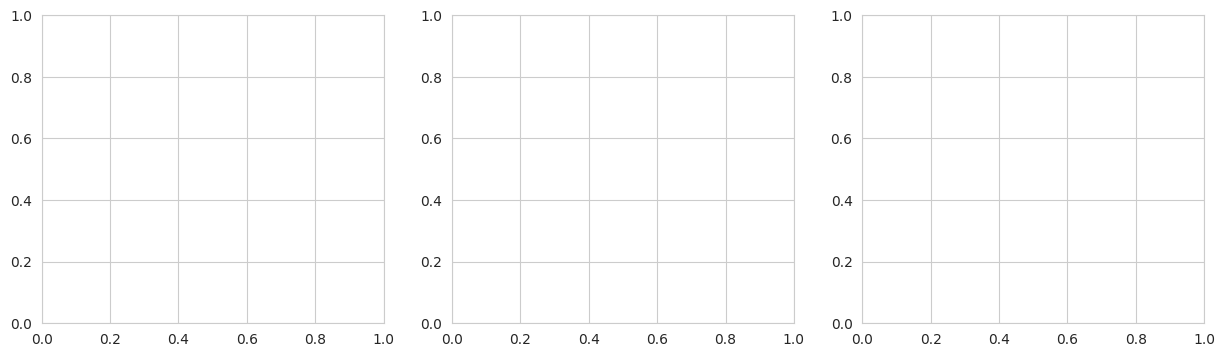

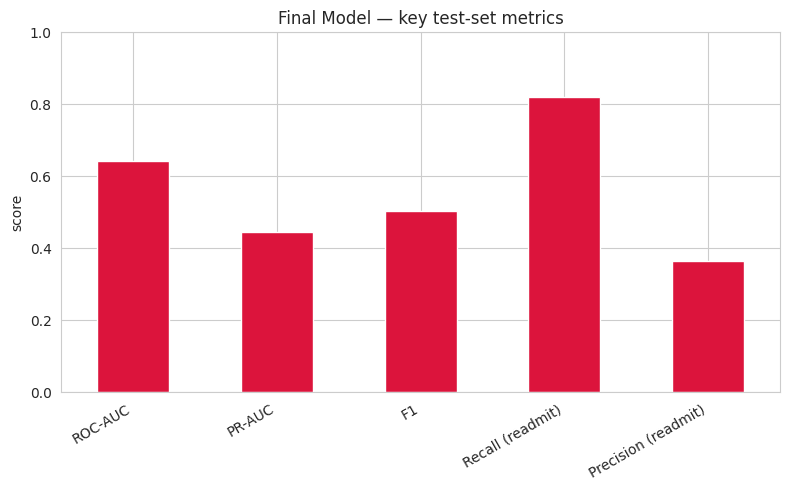

In [34]:
fig, ax = plt.subplots(figsize=(8,5))
final_summary[['ROC-AUC','PR-AUC','F1','Recall (readmit)','Precision (readmit)']].T.plot(
    kind='bar', ax=ax, legend=False, color='crimson')
ax.set_ylim(0,1); ax.set_ylabel('score'); ax.set_title('Final Model — key test-set metrics')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 11. Conclusion

The Final Model — a patient-grouped, chronologically-split, leakage-audited LightGBM + XGBoost ensemble with isotonic calibration and a validation-optimized decision threshold — is evaluated once on a fully held-out test set in §7, with SHAP explanations, error analysis, and a fairness re-check to support it. Its artifacts and a ready-to-use inference function are saved in §8. Use the metrics in §10 as the headline numbers for this model.